In [1]:
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt

In [2]:

base = "/home/georg/data/LEON_P6_forest-agri-change/"

# Load small layer first (reference extent)
natural_forest = rxr.open_rasterio(base + "natural_forest_2020_bugoma.tif", masked=True)
forest_type_esri = rxr.open_rasterio(base + "LULC_ESRI_2019_Bugoma.tif", masked=True)

# Get bounds from reference
bounds = natural_forest.rio.bounds()

# Clip big layers to Bugoma extent (lazy loading)
forest_type_copernicus = rxr.open_rasterio(
    base + "PROBAV_LC100_global_v3.1.2_2019-nrt_Forest-Type-layer_EPSG-4326.tif",
    masked=True
).rio.clip_box(*bounds)

tree_density = rxr.open_rasterio(
    base + "Tree_cover_density_CLMS_2020/LCFM_TCD-10_V100_2020_N00E030_cog/LCFM_TCD-10_V100_2020_N00E030_MAP.tif",
    masked=True
).rio.clip_box(*bounds)

# Reproject all to EPSG:10793
forest_type_cop = forest_type_copernicus.rio.reproject("EPSG:10793")
forest_type_esri = forest_type_esri.rio.reproject("EPSG:10793")
natural_forest = natural_forest.rio.reproject("EPSG:10793")
tree_density = tree_density.rio.reproject("EPSG:10793")

print("Done")

Done


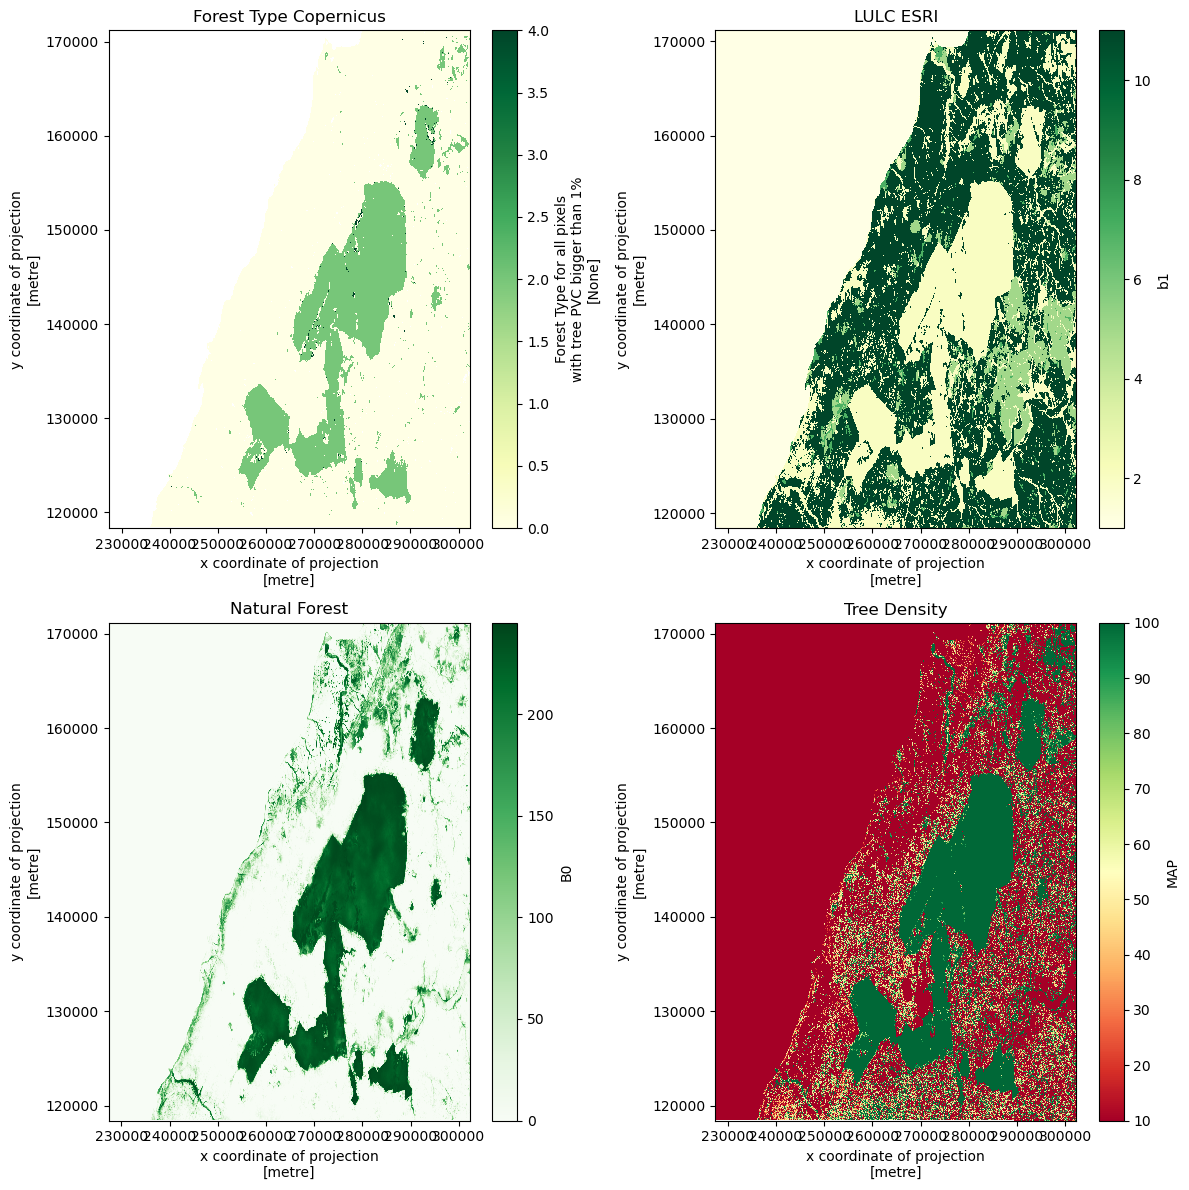

In [ ]:
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# forest_type_cop.plot(ax=axes[0,0], cmap='YlGn')
# axes[0,0].set_title('Forest Type Copernicus')

# forest_type_esri.plot(ax=axes[0,1], cmap='YlGn')
# axes[0,1].set_title('LULC ESRI')

# natural_forest.plot(ax=axes[1,0], cmap='Greens')
# axes[1,0].set_title('Natural Forest')

# tree_density.plot(ax=axes[1,1], cmap='RdYlGn')
# axes[1,1].set_title('Tree Density')

# plt.tight_layout()
# plt.show()

In [3]:

# Resample all to forest_type_esri grid (reference)
tree_density_matched = tree_density.rio.reproject_match(forest_type_esri)
natural_forest_matched = natural_forest.rio.reproject_match(forest_type_esri)

# Create forest mask
forest_mask = (
    (forest_type_esri == 2) & 
    (tree_density_matched > 30) & 
    (natural_forest_matched > 20)
).astype(int)


# Fill NaN with 0
forest_mask = forest_mask.fillna(0).astype('uint8')
forest_mask.rio.write_nodata(None, inplace=True)

<xarray.DataArray (band: 1, y: 5284, x: 7508)> Size: 40MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(1, 5284, 7508), dtype=uint8)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 42kB 1.711e+05 1.711e+05 ... 1.184e+05 1.184e+05
  * x            (x) float64 60kB 2.274e+05 2.274e+05 ... 3.023e+05 3.023e+05
    spatial_ref  int64 8B 0
Attributes: (12/24)
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    copyright:      LCFM project 2020 / Contains modified Copernicus Sentinel...
    creation_time:  2025-06-13T14:20:37Z
    description:    Annual Tree Cover Density at 10 m resolution
    ...             ...
    sensor:         MSI
    time_end:       2020-12-31T23:59:59Z
    time_start:     2020-01-01T00:00:00Z
    version:        V100
    NoData:         255
    long_name:      B0

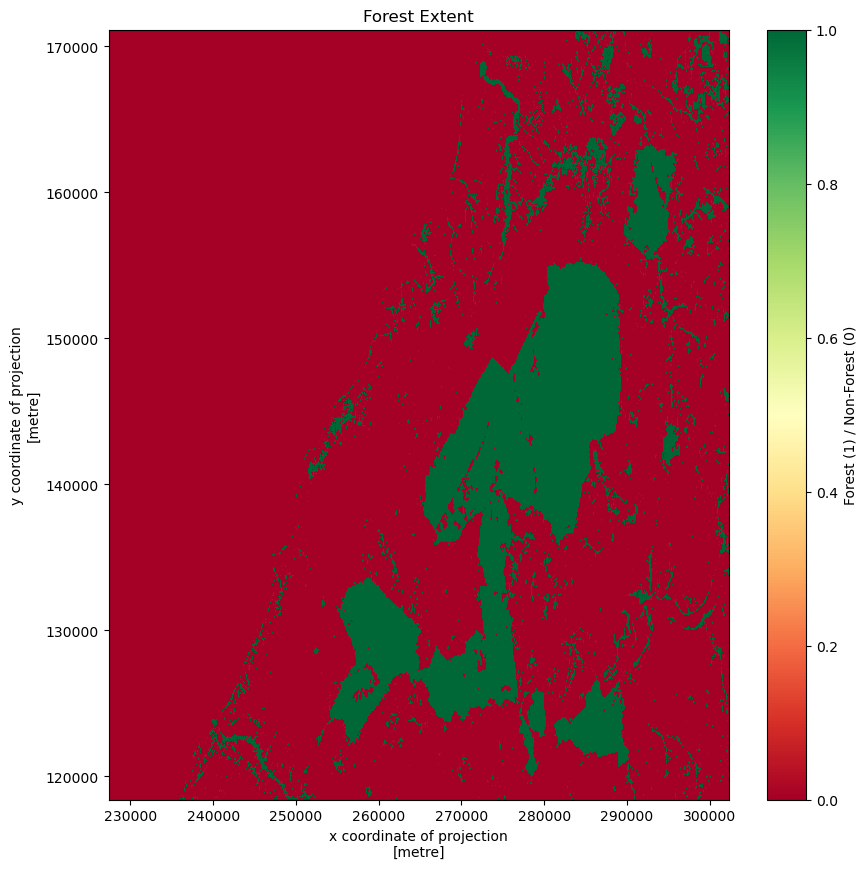

In [ ]:

# # Plot
# fig, ax = plt.subplots(figsize=(10, 10))
# forest_mask[0].plot(ax=ax, cmap='RdYlGn', cbar_kwargs={'label': 'Forest (1) / Non-Forest (0)'})
# ax.set_title('Forest Extent')
# plt.show()

In [ ]:
from scipy.ndimage import label, generate_binary_structure
import numpy as np

# Get pixel size in meters (for area calculation)
pixel_size_x, pixel_size_y = forest_mask.rio.resolution()
pixel_area_m2 = abs(pixel_size_x * pixel_size_y)
pixel_area_ha = pixel_area_m2 / 10000

# 8-connectivity structure (includes diagonals/corners)
structure = generate_binary_structure(2, 2)  # or np.ones((3,3))

# Label connected forest patches with 8-connectivity
labeled, num_patches = label(forest_mask.values[0] == 1, structure=structure)

# Calculate patch sizes in hectares
patch_sizes = np.bincount(labeled.ravel())
patch_sizes_ha = patch_sizes * pixel_area_ha

# Patches >= 1 ha (exclude label 0 = background)
valid_patches = np.where(patch_sizes_ha >= 1)[0]
valid_patches = valid_patches[valid_patches > 0]  # REMOVE BACKGROUND

# Create mask: keep only patches >= 1 ha
forest_filtered = np.isin(labeled, valid_patches).astype('uint8')

# Update forest_mask
forest_mask.values[0] = forest_filtered

print(f"Pixel area: {pixel_area_ha:.4f} ha")
print(f"Original patches: {num_patches}")
print(f"Patches >= 1 ha: {len(valid_patches)-1}")

# # Save
# forest_mask.rio.write_nodata(None, inplace=True)
# forest_mask.rio.to_raster(
#     "/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2019.tif",
#     compress='lzw'
# )

Pixel area: 0.0100 ha
Original patches: 9307
Patches >= 1 ha: 1191


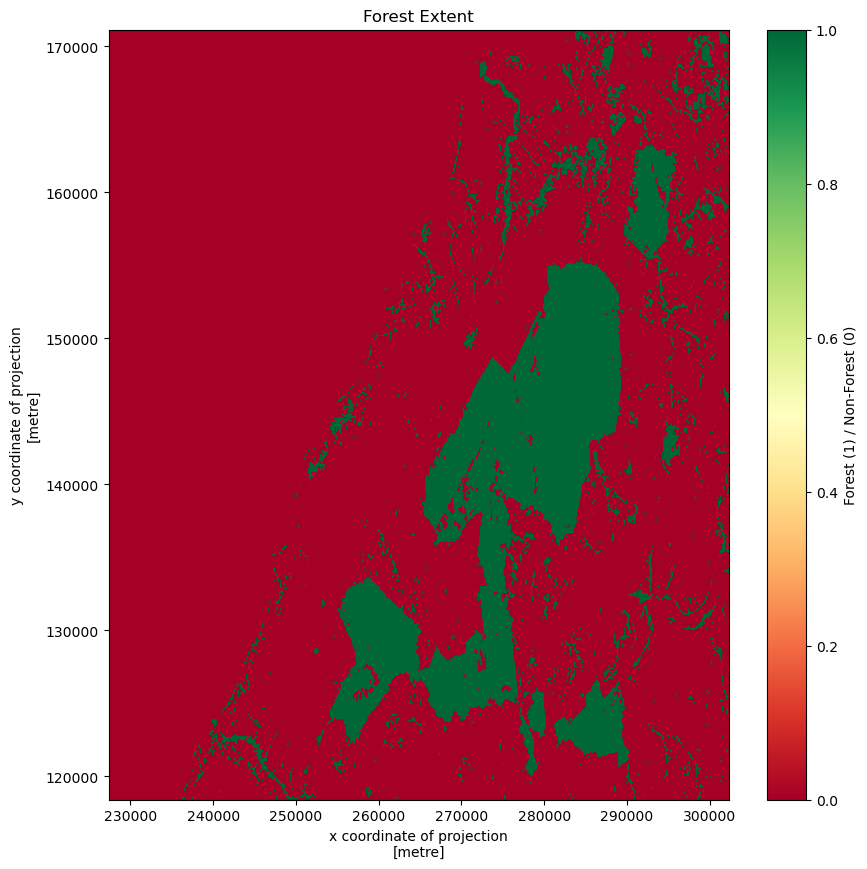

In [5]:

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
forest_mask[0].plot(ax=ax, cmap='RdYlGn', cbar_kwargs={'label': 'Forest (1) / Non-Forest (0)'})
ax.set_title('Forest Extent')
plt.show()

In [6]:
# Save
forest_mask.rio.to_raster(
    "/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2019.tif",
    compress='lzw'
)